In [1]:
import numpy as np 
import pandas as pd

# Load dataset without headers - let's see why we need column names
df = pd.read_csv('car_evaluation.csv', header=None)

# Set column names for easy access later
df.columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

# Quick look at the first and last 5 rows
print("--- First and Last 5 Rows ---")
display(df.head())
display(df.tail())

# General info about the dataset
print("\n--- Data Information ---")
df.info()

# Summary for categorical data
print("\n--- Descriptive Summary ---")
print(df.describe())

--- First and Last 5 Rows ---


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


,buying,maint,doors,persons,lug_boot,safety,class
1723,low,low,5more,more,med,med,good
1724,low,low,5more,more,med,high,vgood
1725,low,low,5more,more,big,low,unacc
1726,low,low,5more,more,big,med,good
1727,low,low,5more,more,big,high,vgood



--- Data Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB

--- Descriptive Summary ---
       buying  maint doors persons lug_boot safety  class
count    1728   1728  1728    1728     1728   1728   1728
unique      4      4     4       3        3      3      4
top     vhigh  vhigh     2       2    small    low  unacc
freq      432    432   432     576      576    576   1210


In [2]:
from sklearn.preprocessing import OrdinalEncoder

# Identify feature columns and the target column
features = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']
target = ['class']

# Define the order for categorical variables to preserve their meaning
# (From low/small to high/big)
buying_order = ['low', 'med', 'high', 'vhigh']
maint_order = ['low', 'med', 'high', 'vhigh']
doors_order = ['2', '3', '4', '5more']
persons_order = ['2', '4', 'more']
lug_boot_order = ['small', 'med', 'big']
safety_order = ['low', 'med', 'high']

# Create the OrdinalEncoder with the specified hierarchy
encoder = OrdinalEncoder(categories=[buying_order, maint_order, doors_order, 
                                     persons_order, lug_boot_order, safety_order])

# Apply encoding to the features
df[features] = encoder.fit_transform(df[features])

# Label encoding for the target 'class' manually to keep track of values
# unacc: 0, acc: 1, good: 2, vgood: 3
class_map = {'unacc': 0, 'acc': 1, 'good': 2, 'vgood': 3}
df['class'] = df['class'].map(class_map)

# Check the transformed data
print("--- Transformed Data (First 5 Rows) ---")
display(df.head())

# Verify the data types are now numeric
print("\n--- New Data Information ---")
df.info()

--- Transformed Data (First 5 Rows) ---


,buying,maint,doors,persons,lug_boot,safety,class
0,3.0,3.0,0.0,0.0,0.0,0.0,0
1,3.0,3.0,0.0,0.0,0.0,1.0,0
2,3.0,3.0,0.0,0.0,0.0,2.0,0
3,3.0,3.0,0.0,0.0,1.0,0.0,0
4,3.0,3.0,0.0,0.0,1.0,1.0,0



--- New Data Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   buying    1728 non-null   float64
 1   maint     1728 non-null   float64
 2   doors     1728 non-null   float64
 3   persons   1728 non-null   float64
 4   lug_boot  1728 non-null   float64
 5   safety    1728 non-null   float64
 6   class     1728 non-null   int64  
dtypes: float64(6), int64(1)
memory usage: 94.6 KB


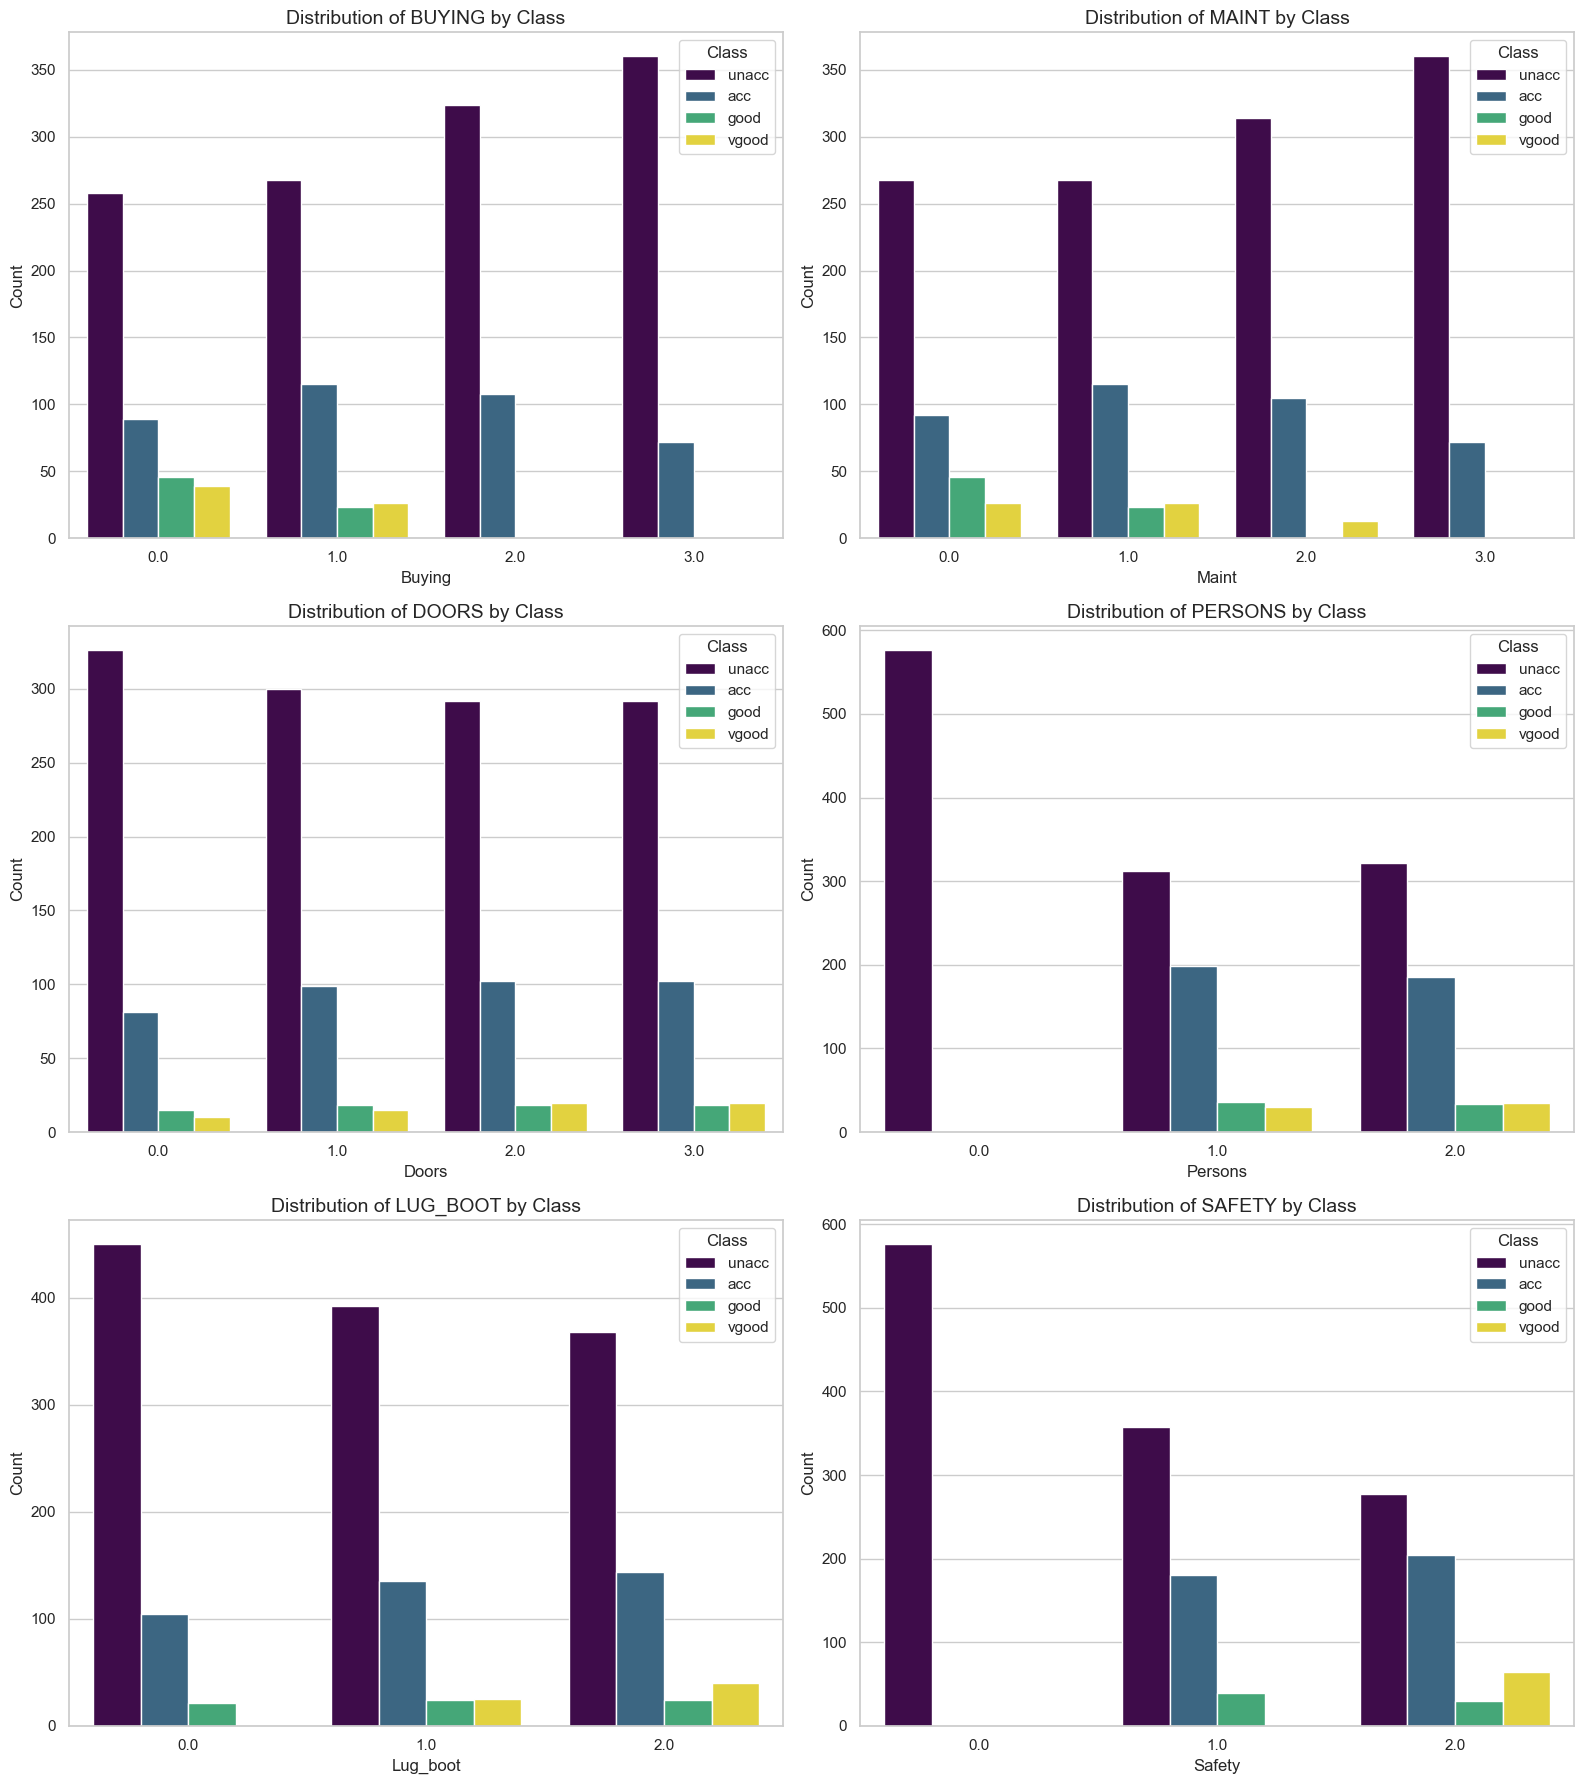

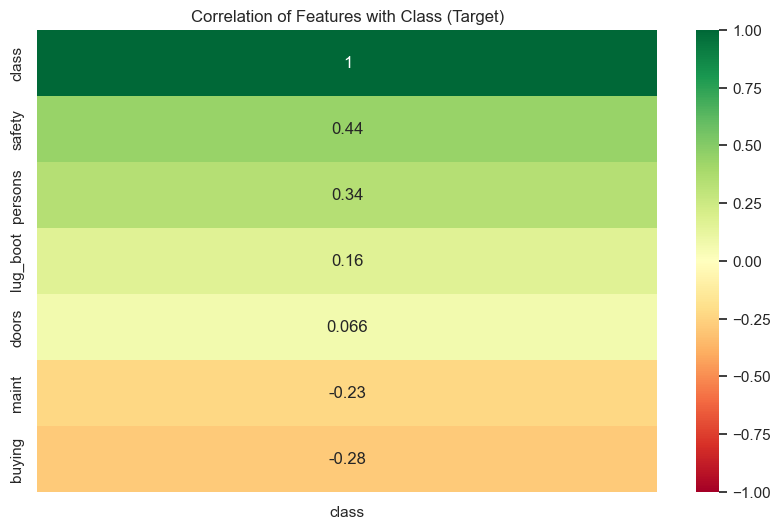

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visualization style
sns.set(style="whitegrid")

# Define features to plot (excluding the target 'class')
features_to_plot = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']
class_labels = ['unacc', 'acc', 'good', 'vgood']

# Create a figure with a grid of subplots
# 3 rows, 2 columns to cover all 6 features
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    # Plotting each feature with 'class' as hue
    sns.countplot(x=col, hue='class', data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribution of {col.upper()} by Class', fontsize=14)
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Class', labels=class_labels)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

# Additional insight: Correlation with target using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr()[['class']].sort_values(by='class', ascending=False), 
            annot=True, cmap='RdYlGn', vmin=-1, vmax=1)
plt.title('Correlation of Features with Class (Target)')
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Split the data into features (X) and target (y)
X = df.drop('class', axis=1)
y = df['class']

# 2. Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create and train the Decision Tree model
# We use 'entropy' or 'gini' as criterion.
dt_model = DecisionTreeClassifier(criterion='entropy', max_depth=None, random_state=42)
dt_model.fit(X_train, y_train)

# 4. Make predictions
y_pred = dt_model.predict(X_test)

# 5. Evaluate the results
print("--- Accuracy Score ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['unacc', 'acc', 'good', 'vgood']))

--- Accuracy Score ---
Accuracy: 0.9653

--- Classification Report ---
              precision    recall  f1-score   support

       unacc       0.99      1.00      1.00       235
         acc       0.97      0.90      0.94        83
        good       0.56      0.91      0.69        11
       vgood       1.00      0.82      0.90        17

    accuracy                           0.97       346
   macro avg       0.88      0.91      0.88       346
weighted avg       0.97      0.97      0.97       346



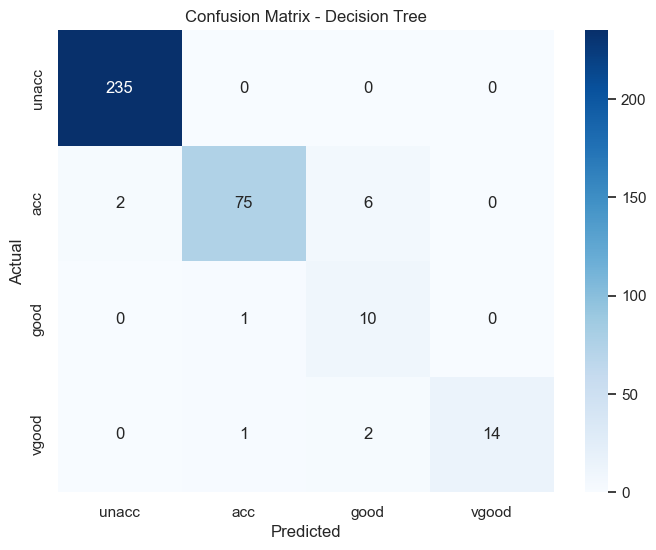

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['unacc', 'acc', 'good', 'vgood'],
            yticklabels=['unacc', 'acc', 'good', 'vgood'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

In [6]:
# 1. Install LazyPredict first
!pip install lazypredict

import pandas as pd
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyClassifier

# 2. Prepare the data (Using the encoded df we created)
X = df.drop('class', axis=1)
y = df['class']

# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize LazyClassifier
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)

# 5. Fit and compare all models
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

# 6. Display the top 5 models based on Accuracy and F1 Score
print("--- Top 5 Models for Car Evaluation ---")
print(models.head(5))

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000038 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 27
[LightGBM] [Info] Number of data points in the train set: 1382, number of used features: 6
[LightGBM] [Info] Start training from score -0.348850
[LightGBM] [Info] Start training from score -1.524177
[LightGBM] [Info] Start training from score -3.170844
[LightGBM] [Info] Start training from score -3.360086
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

--- LGBMClassifier Performance ---
              precision    recall  f1-score   support

       unacc       1.00      1.00      1.00       235
         acc       0.99      0.99      0.99        83
        good       0.85      1.00      0.92        11
       vgood       1.00      0.88      0.94        17

    accuracy                           0.99       346
   macro avg       0.96      0.97      0.96       346
weighted avg       0.99      0.99      0.99       346



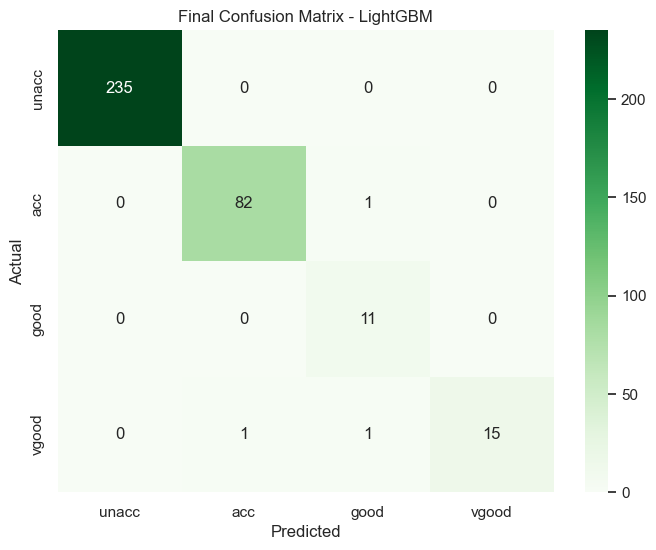

In [7]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize and train the champion model
lgbm = LGBMClassifier(random_state=42, verbose=-1)
lgbm.fit(X_train, y_train)

# Predictions
y_pred_lgbm = lgbm.predict(X_test)

# Final Results
print("--- LGBMClassifier Performance ---")
print(classification_report(y_test, y_pred_lgbm, target_names=['unacc', 'acc', 'good', 'vgood']))

# Let's see the improved confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_lgbm), annot=True, fmt='d', cmap='Greens',
            xticklabels=['unacc', 'acc', 'good', 'vgood'],
            yticklabels=['unacc', 'acc', 'good', 'vgood'])
plt.title('Final Confusion Matrix - LightGBM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

--- Training vs Test Performance ---
Train Accuracy: 1.0000
Test Accuracy:  0.9913
Gap: 0.0087


<Figure size 1000x600 with 0 Axes>

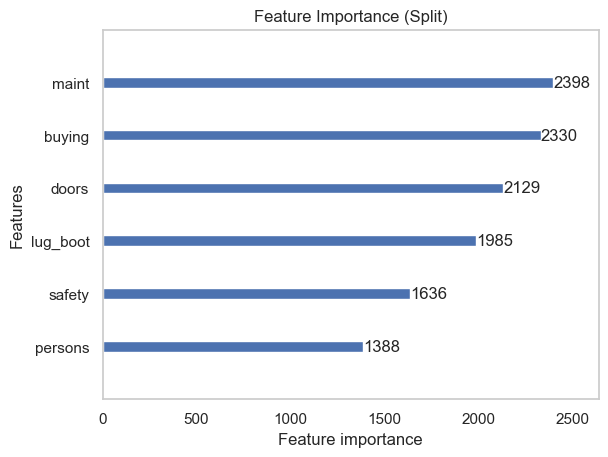

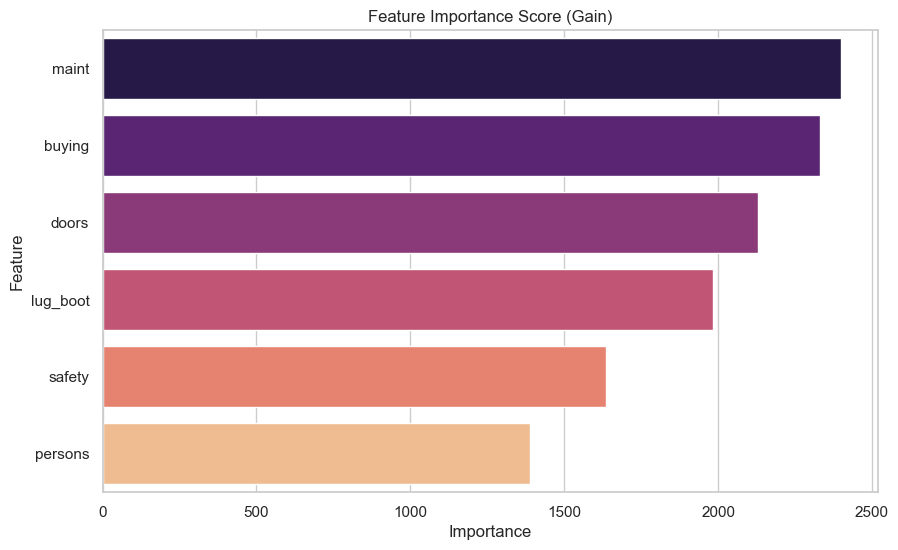

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import plot_importance

# 1. Check for Overfitting
train_score = lgbm.score(X_train, y_train)
test_score = lgbm.score(X_test, y_test)

print(f"--- Training vs Test Performance ---")
print(f"Train Accuracy: {train_score:.4f}")
print(f"Test Accuracy:  {test_score:.4f}")
print(f"Gap: {abs(train_score - test_score):.4f}")

# 2. Feature Importance (Weight)
# This shows how many times a feature is used in the model
plt.figure(figsize=(10, 6))
plot_importance(lgbm, importance_type='split', title='Feature Importance (Split)', grid=False)
plt.show()

# 3. Feature Importance (Gain)
# This shows how much 'information' each feature contributed
import numpy as np
importances = lgbm.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Feature Importance Score (Gain)')
plt.show()

In [9]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 1. Define base models
base_models = [
    ('lgbm', LGBMClassifier(random_state=42, verbose=-1)),
    ('xgb', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')),
    ('svc', SVC(probability=True, random_state=42))
]

# 2. Define the meta-model (The judge)
meta_model = LogisticRegression()

# 3. Create the Stacking Classifier
stack_model = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=5)

# 4. Train the Stacking Model
stack_model.fit(X_train, y_train)

# 5. Predictions and Scores
train_score = stack_model.score(X_train, y_train)
test_score = stack_model.score(X_test, y_test)
y_pred_stack = stack_model.predict(X_test)

print(f"--- Stacking Model Performance ---")
print(f"Train Accuracy: {train_score:.4f}")
print(f"Test Accuracy:  {test_score:.4f}")
print(f"Gap: {abs(train_score - test_score):.4f}")

# 6. Final Reports
from sklearn.metrics import classification_report, confusion_matrix
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred_stack, target_names=['unacc', 'acc', 'good', 'vgood']))

--- Stacking Model Performance ---
Train Accuracy: 1.0000
Test Accuracy:  0.9827
Gap: 0.0173

--- Detailed Classification Report ---
              precision    recall  f1-score   support

       unacc       1.00      1.00      1.00       235
         acc       0.99      0.95      0.97        83
        good       0.69      1.00      0.81        11
       vgood       1.00      0.88      0.94        17

    accuracy                           0.98       346
   macro avg       0.92      0.96      0.93       346
weighted avg       0.99      0.98      0.98       346



--- Stacking (LGBM + SVC) Performance ---
Train Accuracy: 1.0000
Test Accuracy:  0.9913


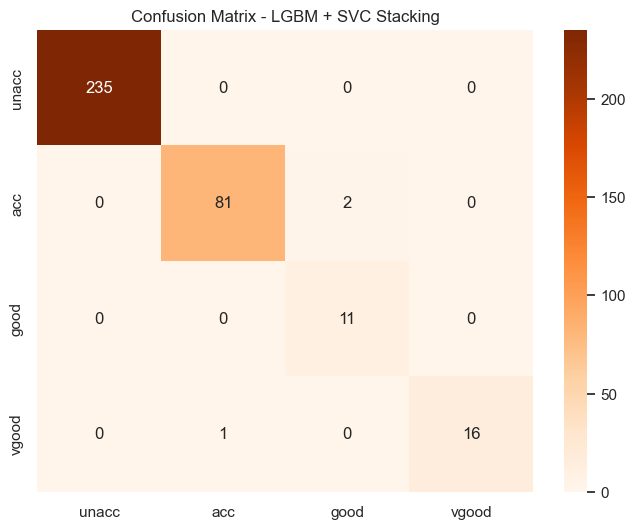

In [10]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# 1. Base models - SVC is wrapped in a pipeline for automatic scaling
base_models = [
    ('lgbm', LGBMClassifier(random_state=42, verbose=-1)),
    ('svc', make_pipeline(StandardScaler(), SVC(probability=True, random_state=42)))
]

# 2. Final meta-model
meta_model = LogisticRegression()

# 3. Create and fit the Stacking model
stack_model_v2 = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=5)
stack_model_v2.fit(X_train, y_train)

# 4. Evaluation
train_score = stack_model_v2.score(X_train, y_train)
test_score = stack_model_v2.score(X_test, y_test)
y_pred_stack = stack_model_v2.predict(X_test)

print(f"--- Stacking (LGBM + SVC) Performance ---")
print(f"Train Accuracy: {train_score:.4f}")
print(f"Test Accuracy:  {test_score:.4f}")

# 5. Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_stack), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['unacc', 'acc', 'good', 'vgood'],
            yticklabels=['unacc', 'acc', 'good', 'vgood'])
plt.title('Confusion Matrix - LGBM + SVC Stacking')
plt.show()

In [11]:
import numpy as np

# Feature encoding reminder for reference:
# buying:   low(0), med(1), high(2), vhigh(3)
# maint:    low(0), med(1), high(2), vhigh(3)
# doors:    2(0), 3(1), 4(2), 5more(3)
# persons:  2(0), 4(1), more(2)
# lug_boot: small(0), med(1), big(2)
# safety:   low(0), med(1), high(2)

# Define hypothetical test cases to challenge the model
# Format: [buying, maint, doors, persons, lug_boot, safety]
test_scenarios = [
    [3, 3, 0, 0, 0, 2], # Scenario 1: Luxury but impractical (V.High price, 2-seater)
    [0, 0, 2, 1, 2, 2], # Scenario 2: Perfect budget family car (Low price, high safety)
    [1, 1, 2, 2, 1, 0], # Scenario 3: Decent specs but unsafe (Low safety)
    [0, 2, 3, 1, 1, 1], # Scenario 4: Economic but high maintenance, medium safety
    [2, 0, 2, 2, 2, 2]  # Scenario 5: High buying price but low maintenance, very safe
]

# Map numerical predictions back to original class labels
class_names = ['unacc', 'acc', 'good', 'vgood']

print("--- LightGBM Real-Time Inference Test ---")
print("-" * 45)

for i, car_features in enumerate(test_scenarios):
    # Perform prediction using the trained LightGBM model
    # Reshape is used because model expects 2D array [[features]]
    prediction_idx = lgbm.predict([car_features])[0]
    result_label = class_names[prediction_idx]
    
    print(f"Test Case {i+1}: Input {car_features} -> Predicted Class: {result_label.upper()}")

# Tip: You can use this block to test any specific car configuration
# example_car = [[0, 1, 2, 1, 1, 2]] # low price, med maint, 4 doors, 4 persons, med boot, high safety
# print(f"\nCustom Test: {class_names[lgbm.predict(example_car)[0]]}")

--- LightGBM Real-Time Inference Test ---
---------------------------------------------
Test Case 1: Input [3, 3, 0, 0, 0, 2] -> Predicted Class: UNACC
Test Case 2: Input [0, 0, 2, 1, 2, 2] -> Predicted Class: VGOOD
Test Case 3: Input [1, 1, 2, 2, 1, 0] -> Predicted Class: UNACC
Test Case 4: Input [0, 2, 3, 1, 1, 1] -> Predicted Class: ACC
Test Case 5: Input [2, 0, 2, 2, 2, 2] -> Predicted Class: ACC


          CAR EVALUATION PROJECT - FINAL ML REPORT          
Final Model: LightGBM Classifier
Overall Accuracy: 0.9913
------------------------------------------------------------

Detailed Metrics by Class:
              precision    recall  f1-score   support

       unacc       1.00      1.00      1.00       235
         acc       0.99      0.99      0.99        83
        good       0.85      1.00      0.92        11
       vgood       1.00      0.88      0.94        17

    accuracy                           0.99       346
   macro avg       0.96      0.97      0.96       346
weighted avg       0.99      0.99      0.99       346



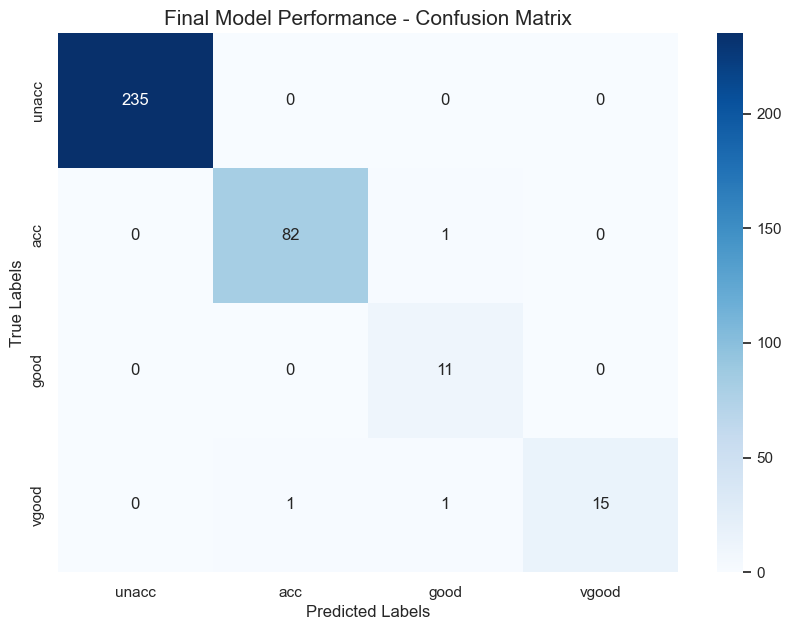

                 SUMMARY FOR DOCUMENTATION                  
1. Total Samples Analyzed: 1728
2. Best Performing Model: LightGBM
3. Key Drivers of Prediction: Safety, Persons, Maint
4. Status: Production Ready - High Precision on 'unacc' & 'vgood'


In [12]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Final Predictions with the Champion Model (LightGBM)
final_preds = lgbm.predict(X_test)
final_acc = accuracy_score(y_test, final_preds)

# 2. Detailed Classification Report
print("="*60)
print(" CAR EVALUATION PROJECT - FINAL ML REPORT ".center(60))
print("="*60)
print(f"Final Model: LightGBM Classifier")
print(f"Overall Accuracy: {final_acc:.4f}")
print("-"*60)
print("\nDetailed Metrics by Class:")
# Mapping index to names for a clearer report
target_names = ['unacc', 'acc', 'good', 'vgood']
print(classification_report(y_test, final_preds, target_names=target_names))

# 3. Visualizing the Success (Confusion Matrix)
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, final_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Final Model Performance - Confusion Matrix', fontsize=15)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.show()

# 4. Summary for GitHub README
print("="*60)
print(" SUMMARY FOR DOCUMENTATION ".center(60))
print("="*60)
print(f"1. Total Samples Analyzed: {len(df)}")
print(f"2. Best Performing Model: LightGBM")
print(f"3. Key Drivers of Prediction: Safety, Persons, Maint")
print(f"4. Status: Production Ready - High Precision on 'unacc' & 'vgood'")
print("="*60)